<a href="https://colab.research.google.com/github/aparna-2001/nifty50-stock-price-forecasting/blob/main/Data_collection_EDA_Decomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import yfinance as yf
import matplotlib.pyplot as plt

In [11]:
df = yf.download('^NSEI', start='2018-01-01', end='2026-01-01')

print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")


/tmp/ipython-input-456/3219599532.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^NSEI', start='2018-01-01', end='2026-01-01')
[*********************100%***********************]  1 of 1 completed

Date range: 2018-01-02 to 2025-12-31
Total trading days: 1972


In [12]:
print(df.shape)
print(df.head())
print(df.isnull().sum())

(1972, 5)
Price              Close          High           Low          Open  Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI   ^NSEI
Date                                                                      
2018-01-02  10442.200195  10495.200195  10404.650391  10477.549805  153400
2018-01-03  10443.200195  10503.599609  10429.549805  10482.650391  167300
2018-01-04  10504.799805  10513.000000  10441.450195  10469.400391  174900
2018-01-05  10558.849609  10566.099609  10520.099609  10534.250000  180900
2018-01-08  10623.599609  10631.200195  10588.549805  10591.700195  169000
Price   Ticker
Close   ^NSEI     0
High    ^NSEI     0
Low     ^NSEI     0
Open    ^NSEI     0
Volume  ^NSEI     0
dtype: int64


Date range  : 2018-01-02 00:00:00 to 2025-12-31 00:00:00
Total days  : 1972
Columns     : [('Close', '^NSEI'), ('High', '^NSEI'), ('Low', '^NSEI'), ('Open', '^NSEI'), ('Volume', '^NSEI')]


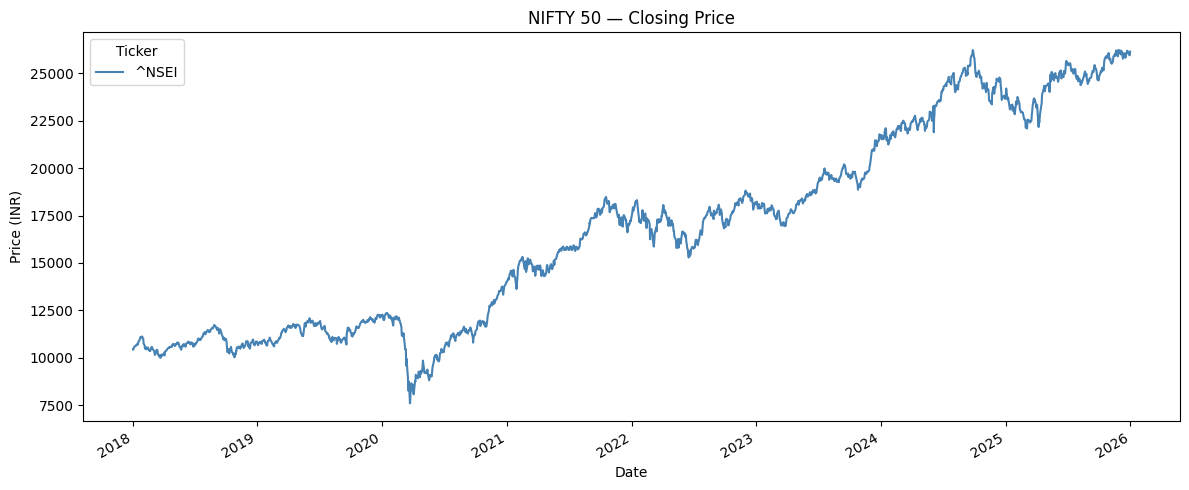

In [13]:
# Basic info
print(f"Date range  : {df.index[0]} to {df.index[-1]}")
print(f"Total days  : {len(df)}")
print(f"Columns     : {df.columns.tolist()}")

# Quick plot
df['Close'].plot(figsize=(12,5), title='NIFTY 50 — Closing Price', color='steelblue')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

In [15]:
# Flattening multi-level columns first

df.columns = df.columns.droplevel(1)
df = df[['Close', 'Open', 'High', 'Low', 'Volume']]

print(df.head())
print(df.describe())

Price              Close          Open          High           Low  Volume
Date                                                                      
2018-01-02  10442.200195  10477.549805  10495.200195  10404.650391  153400
2018-01-03  10443.200195  10482.650391  10503.599609  10429.549805  167300
2018-01-04  10504.799805  10469.400391  10513.000000  10441.450195  174900
2018-01-05  10558.849609  10534.250000  10566.099609  10520.099609  180900
2018-01-08  10623.599609  10591.700195  10631.200195  10588.549805  169000
Price         Close          Open          High           Low        Volume
count   1972.000000   1972.000000   1972.000000   1972.000000  1.972000e+03
mean   16713.568267  16722.768918  16800.039418  16622.282445  3.715888e+05
std     5204.207512   5202.223873   5217.087455   5190.576039  1.949607e+05
min     7610.250000   7735.149902   8036.950195   7511.100098  0.000000e+00
25%    11514.500244  11531.562256  11572.949951  11449.962402  2.460000e+05
50%    16965.400391

*Distribution of daily returns*

<Axes: >

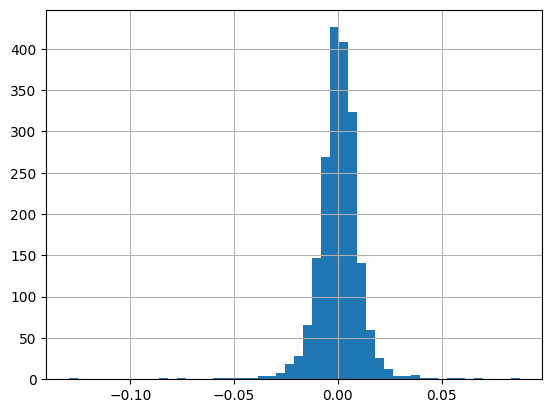

In [16]:
df['Daily_Return'] = df['Close'].pct_change()
df['Daily_Return'].hist(bins=50)

*Rolling statistics*

<Axes: xlabel='Date'>

<Figure size 1200x600 with 0 Axes>

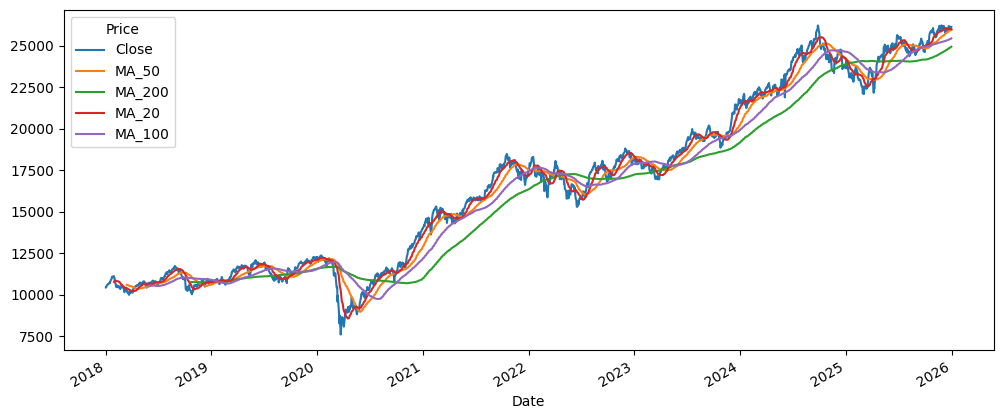

In [35]:
#based on mean


df['MA_50']  = df['Close'].rolling(50).mean()
df['MA_200'] = df['Close'].rolling(200).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
df['MA_100'] = df['Close'].rolling(100).mean()


df[['Close', 'MA_50', 'MA_200','MA_20', 'MA_100']].plot(figsize=(12,5))


* Long term moving average is more useful to identify where the market is heading

* Short term prediction

* Long term prediction

<Axes: xlabel='Date'>

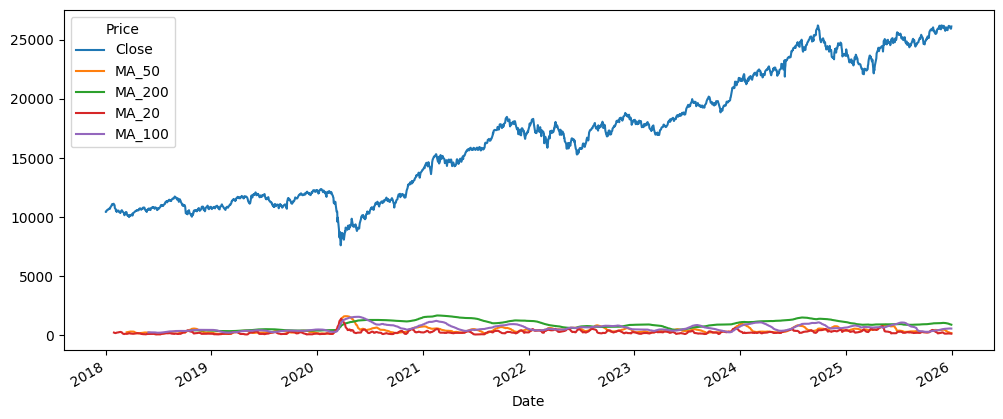

In [36]:

#based on standard deviation

df['MA_50']  = df['Close'].rolling(50).std()
df['MA_200'] = df['Close'].rolling(200).std()
df['MA_20'] = df['Close'].rolling(20).std()
df['MA_100'] = df['Close'].rolling(100).std()


df[['Close', 'MA_50', 'MA_200','MA_20', 'MA_100']].plot(figsize=(12,5))


*volatility*

<Axes: title={'center': 'NIFTY 50 — Volatility'}, xlabel='Date'>

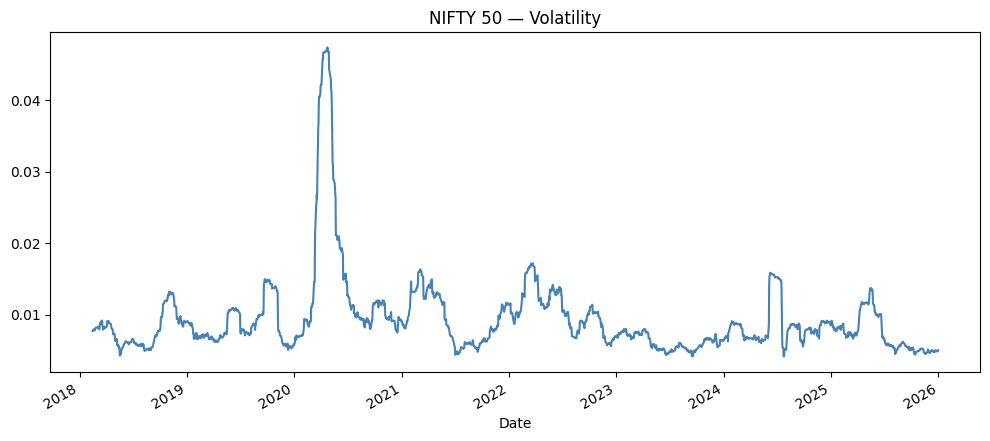

In [22]:
df['Volatility'] = df['Daily_Return'].rolling(30).std()
df['Volatility'].plot(figsize=(12,5), title='NIFTY 50 — Volatility', color='steelblue')

*volume analysis*

In [20]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Close'])
print(f'p-value: {result[1]}')
# p > 0.05 → non-stationary (expected)

p-value: 0.9586323366211918


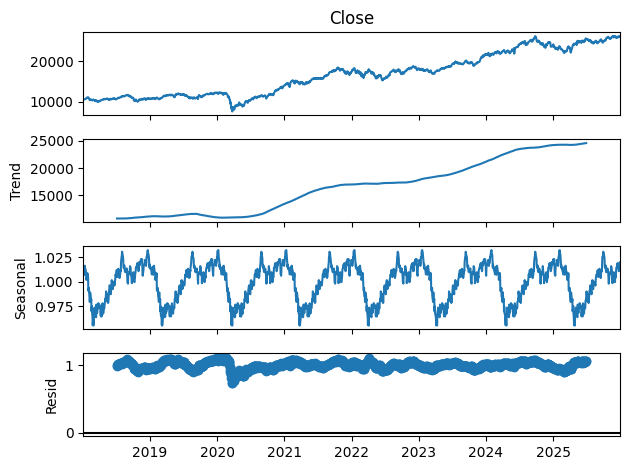

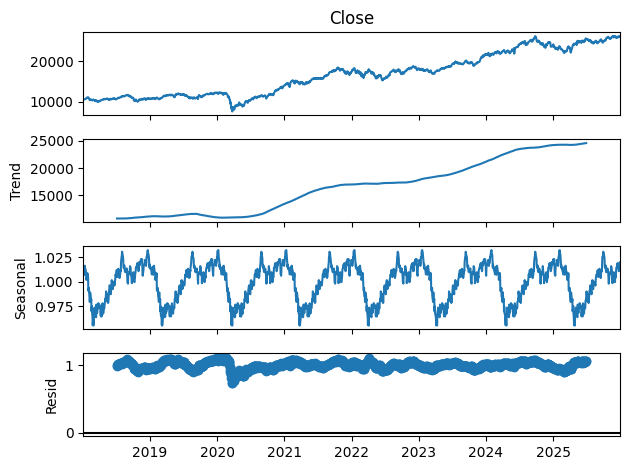

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose
decompose = seasonal_decompose(df['Close'], model='multiplicative', period=252)
decompose.plot()